In [1]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np
from rasterio.mask import mask
from rasterio.enums import Resampling

In [2]:
# Load elevation raster
with rasterio.open("elevation_raster_data.tif") as src:
    raster_src = src
    elevation = src.read(1)
    raster_extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]
    raster_crs = src.crs

    downsample_factor = 1
    new_height = int(src.height * downsample_factor)
    new_width = int(src.width * downsample_factor)

    z_data = src.read(
        1,
        out_shape=(new_height, new_width),
        resampling=Resampling.bilinear
    )
    

# Load GeoJSON
gdf = gpd.read_file("../exports/ghe_locations.geojson")

# Make sure GeoJSON uses the same CRS as the raster
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)


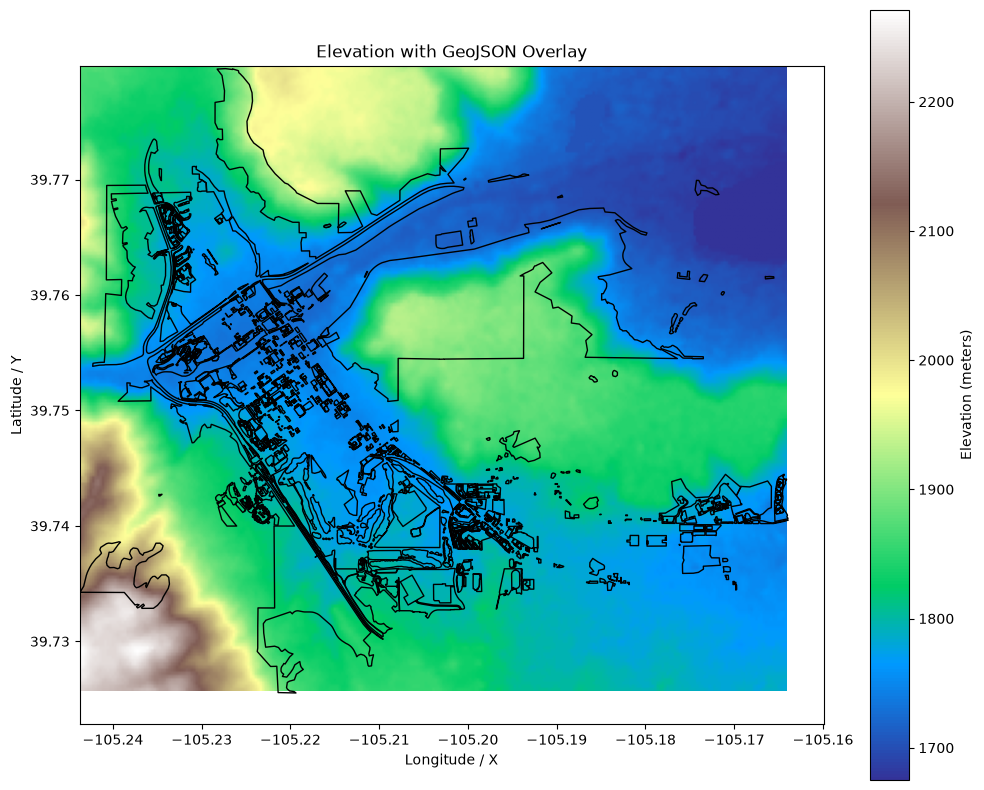

In [3]:
# Create plot
fig, ax = plt.subplots(figsize=(12, 10))

# Display elevation
image = ax.imshow(
    elevation,
    extent=raster_extent,
    cmap="terrain",
    origin="upper"
)

# Overlay GeoJSON
gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.0
)

# Elevation legend/colorbar
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Elevation (meters)")

ax.set_xlabel("Longitude / X")
ax.set_ylabel("Latitude / Y")
ax.set_title("Elevation with GeoJSON Overlay")

plt.show()

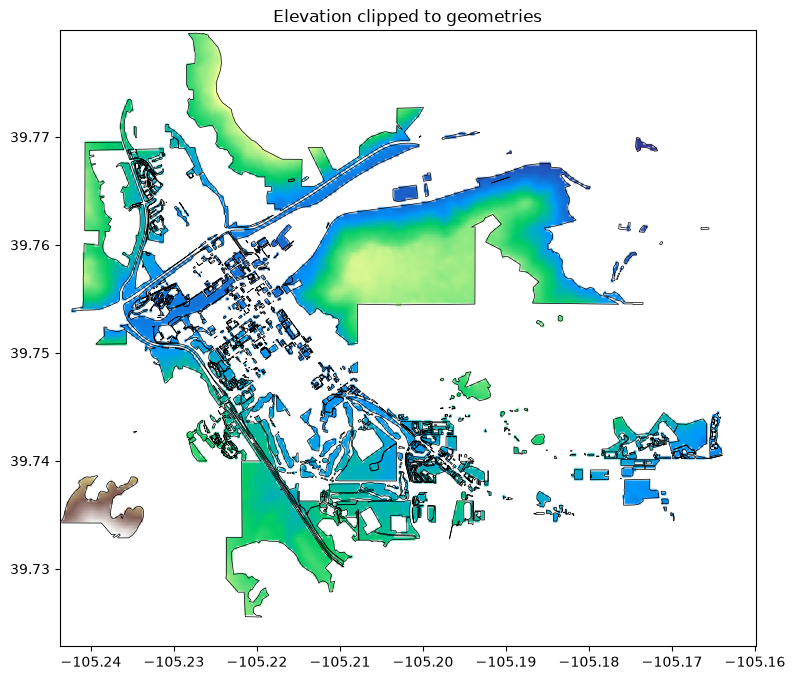

In [4]:
elevation = rasterio.open('elevation_raster_data.tif')

if gdf.crs != elevation.crs:
    gdf = gdf.to_crs(elevation.crs)

geoms = gdf.geometry.values

out_image, out_transform = mask(elevation, geoms, crop=True, filled=False)
out_image = out_image[0]

fig, ax = plt.subplots(figsize=(10, 8))
show(out_image, transform=out_transform, ax=ax, cmap="terrain")
gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)  # overlay geometry outlines
plt.title("Elevation clipped to geometries")
plt.show()

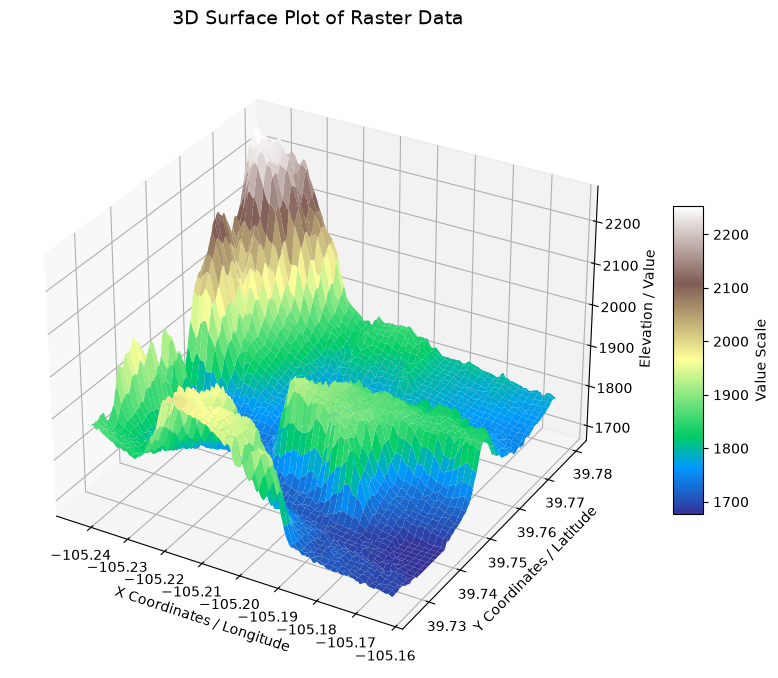

In [5]:
# Generate X and Y coordinates based on the downsampled spatial extent
bounds = src.bounds
x_coords = np.linspace(bounds.left, bounds.right, new_width)
y_coords = np.linspace(bounds.bottom, bounds.top, new_height)
x_mesh, y_mesh = np.meshgrid(x_coords, y_coords)

# 2. Mask out "no data" values (optional but recommended for clean plots)
if src.nodata is not None:
    z_data = np.ma.masked_equal(z_data, src.nodata)

# 3. Create the 3D Surface Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(
    x_mesh, y_mesh, z_data, 
    cmap='terrain',          # Good colormap for elevation data
    edgecolor='none', 
    linewidth=0, 
    antialiased=True
)

# 4. Add formatting and labels
ax.set_title("3D Surface Plot of Raster Data", fontsize=14, pad=20)
ax.set_xlabel("X Coordinates / Longitude")
ax.set_ylabel("Y Coordinates / Latitude")
ax.set_zlabel("Elevation / Value")

# Add a color bar map to show values
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Value Scale")

plt.show()
